# Masked Auto-Encoder

Dataset source: https://www.kaggle.com/datasets/umairshahpirzada/birds-20-species-image-classification

Base code: https://www.kaggle.com/code/spsayakpaul/mae-keras

In [1]:
import os
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import random

# Setting seeds for reproducibility.
SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [15]:
BUFFER_SIZE = 1024
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 20

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2

EPOCHS = 50

IMAGE_SIZE = 48  # We will resize input images to this size.
PATCH_SIZE = 6  # Size of the patches to be extracted from the input images.
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.1  

LAYER_NORM_EPS = 1e-6
ENC_PROJECTION_DIM = 128
DEC_PROJECTION_DIM = 64
ENC_NUM_HEADS = 4
ENC_LAYERS = 6
DEC_NUM_HEADS = 4
DEC_LAYERS = (
    2  # The decoder is lightweight but should be reasonably deep for reconstruction.
)
ENC_TRANSFORMER_UNITS = [
    ENC_PROJECTION_DIM * 2,
    ENC_PROJECTION_DIM,
]  # Size of the transformer layers.
DEC_TRANSFORMER_UNITS = [
    DEC_PROJECTION_DIM * 2,
    DEC_PROJECTION_DIM,
]

In [16]:
DATASET_PATH = "C:/Users/grego/Documents/NVIDIA DLI/Notebooks/My Notebooks/data/birds-20"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH,"train"),
    validation_split=0.2,
    label_mode = None,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH,"train"),
    validation_split=0.2,
    label_mode = None,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)


Found 3208 files belonging to 1 classes.
Using 2567 files for training.
Found 3208 files belonging to 1 classes.
Using 641 files for validation.


In [17]:
class Patches(layers.Layer):
    def __init__(self, patch_size=PATCH_SIZE, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

        # Assuming the image has three channels each patch would be
        # of size (patch_size, patch_size, 3).
        self.resize = layers.Reshape((-1, patch_size * patch_size * 3))

    def call(self, images):
        # Create patches from the input images
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )

        # Reshape the patches to (batch, num_patches, patch_area) and return it.
        patches = self.resize(patches)
        return patches

    def show_patched_image(self, images, patches):
        # This is a utility function which accepts a batch of images and its
        # corresponding patches and help visualize one image and its patches
        # side by side.
        idx = np.random.choice(patches.shape[0])
        print(f"Index selected: {idx}.")

        plt.figure(figsize=(4, 4))
        plt.imshow(keras.utils.array_to_img(images[idx]))
        plt.axis("off")
        plt.show()

        n = int(np.sqrt(patches.shape[1]))
        plt.figure(figsize=(4, 4))
        for i, patch in enumerate(patches[idx]):
            ax = plt.subplot(n, n, i + 1)
            patch_img = tf.reshape(patch, (self.patch_size, self.patch_size, 3))
            plt.imshow(keras.utils.img_to_array(patch_img))
            plt.axis("off")
        plt.show()

        # Return the index chosen to validate it outside the method.
        return idx

    # taken from https://stackoverflow.com/a/58082878/10319735
    def reconstruct_from_patch(self, patch):
        # This utility function takes patches from a *single* image and
        # reconstructs it back into the image. This is useful for the train
        # monitor callback.
        num_patches = patch.shape[0]
        n = int(np.sqrt(num_patches))
        patch = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))
        rows = tf.split(patch, n, axis=0)
        rows = [tf.concat(tf.unstack(x), axis=1) for x in rows]
        reconstructed = tf.concat(rows, axis=0)
        return reconstructed

In [18]:
def get_augmentation_model():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            # layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        ],
        name="test_data_augmentation",
    )
    return model

Index selected: 28.


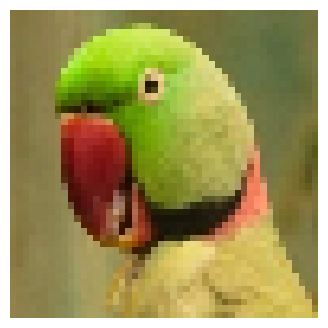

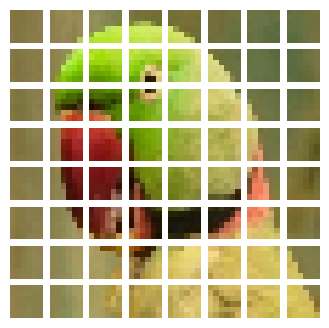

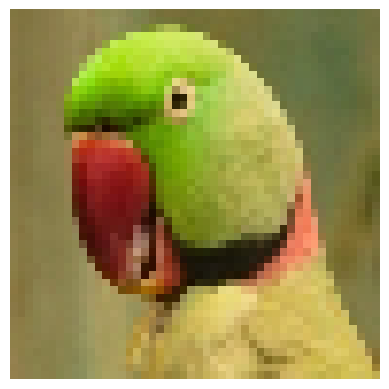

In [19]:
# Get a batch of images.
image_batch = next(iter(train_ds))

augmentation_model = get_augmentation_model()
augmented_images = augmentation_model(image_batch)

# Define the patch layer.
patch_layer = Patches()

# Get the patches from the batched images.
patches = patch_layer(images=augmented_images)

# Now pass the images and the corresponding patches
# to the `show_patched_image` method.
random_index = patch_layer.show_patched_image(images=augmented_images, patches=patches)

# Chose the same chose image and try reconstructing the patches
# into the original image.
image = patch_layer.reconstruct_from_patch(patches[random_index])
plt.imshow(image)
plt.axis("off")
plt.show()

In [20]:
val_ds

<BatchDataset element_spec=TensorSpec(shape=(None, 48, 48, 3), dtype=tf.float32, name=None)>

In [21]:
class PatchEncoder(layers.Layer):
    def __init__(
        self,
        patch_size=PATCH_SIZE,
        projection_dim=ENC_PROJECTION_DIM,
        mask_proportion=MASK_PROPORTION,
        downstream=False,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.projection_dim = projection_dim
        self.mask_proportion = mask_proportion
        self.downstream = downstream

        # This is a trainable mask token initialized randomly from a normal
        # distribution.
        self.mask_token = tf.Variable(
            tf.random.normal([1, patch_size * patch_size * 3]), trainable=True
        )

    def build(self, input_shape):
        (_, self.num_patches, self.patch_area) = input_shape

        # Create the projection layer for the patches.
        self.projection = layers.Dense(units=self.projection_dim)

        # Create the positional embedding layer.
        self.position_embedding = layers.Embedding(
            input_dim=self.num_patches, output_dim=self.projection_dim
        )

        # Number of patches that will be masked.
        self.num_mask = int(self.mask_proportion * self.num_patches)

    def call(self, patches):
        # Get the positional embeddings.
        batch_size = tf.shape(patches)[0]
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        pos_embeddings = self.position_embedding(positions[tf.newaxis, ...])
        pos_embeddings = tf.tile(
            pos_embeddings, [batch_size, 1, 1]
        )  # (B, num_patches, projection_dim)

        # Embed the patches.
        patch_embeddings = (
            self.projection(patches) + pos_embeddings
        )  # (B, num_patches, projection_dim)

        if self.downstream:
            return patch_embeddings
        else:
            mask_indices, unmask_indices = self.get_random_indices(batch_size)
            # The encoder input is the unmasked patch embeddings. Here we gather
            # all the patches that should be unmasked.
            unmasked_embeddings = tf.gather(
                patch_embeddings, unmask_indices, axis=1, batch_dims=1
            )  # (B, unmask_numbers, projection_dim)

            # Get the unmasked and masked position embeddings. We will need them
            # for the decoder.
            unmasked_positions = tf.gather(
                pos_embeddings, unmask_indices, axis=1, batch_dims=1
            )  # (B, unmask_numbers, projection_dim)
            masked_positions = tf.gather(
                pos_embeddings, mask_indices, axis=1, batch_dims=1
            )  # (B, mask_numbers, projection_dim)

            # Repeat the mask token number of mask times.
            # Mask tokens replace the masks of the image.
            mask_tokens = tf.repeat(self.mask_token, repeats=self.num_mask, axis=0)
            mask_tokens = tf.repeat(
                mask_tokens[tf.newaxis, ...], repeats=batch_size, axis=0
            )

            # Get the masked embeddings for the tokens.
            masked_embeddings = self.projection(mask_tokens) + masked_positions
            return (
                unmasked_embeddings,  # Input to the encoder.
                masked_embeddings,  # First part of input to the decoder.
                unmasked_positions,  # Added to the encoder outputs.
                mask_indices,  # The indices that were masked.
                unmask_indices,  # The indices that were unmaksed.
            )

    def get_random_indices(self, batch_size):
        # Create random indices from a uniform distribution and then split
        # it into mask and unmask indices.
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

    def generate_masked_image(self, patches, unmask_indices):
        # Choose a random patch and it corresponding unmask index.
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]

        # Build a numpy array of same shape as patch.
        new_patch = np.zeros_like(patch)

        # Iterate of the new_patch and plug the unmasked patches.
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

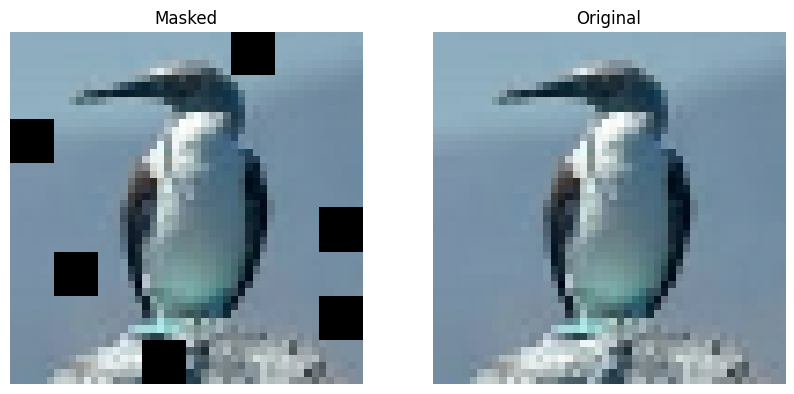

In [22]:
# Create the patch encoder layer.
patch_encoder = PatchEncoder()

# Get the embeddings and positions.
(
    unmasked_embeddings,
    masked_embeddings,
    unmasked_positions,
    mask_indices,
    unmask_indices,
) = patch_encoder(patches=patches)


# Show a maksed patch image.
new_patch, random_index = patch_encoder.generate_masked_image(patches, unmask_indices)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
img = patch_layer.reconstruct_from_patch(new_patch)
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Masked")
plt.subplot(1, 2, 2)
img = augmented_images[random_index]
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Original")
plt.show()

In [23]:
def mlp(x, dropout_rate, hidden_units):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [24]:
def create_encoder(num_heads=ENC_NUM_HEADS, num_layers=ENC_LAYERS):
    inputs = layers.Input((None, ENC_PROJECTION_DIM))
    x = inputs

    for _ in range(num_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=ENC_PROJECTION_DIM, dropout=0.1
        )(x1, x1)

        # Skip connection 1.
        x2 = layers.Add()([attention_output, x])

        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

        # MLP.
        x3 = mlp(x3, hidden_units=ENC_TRANSFORMER_UNITS, dropout_rate=0.1)

        # Skip connection 2.
        x = layers.Add()([x3, x2])

    outputs = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)
    return keras.Model(inputs, outputs, name="mae_encoder")

In [25]:
def create_decoder(
    num_layers=DEC_LAYERS, num_heads=DEC_NUM_HEADS, image_size=IMAGE_SIZE
):
    inputs = layers.Input((NUM_PATCHES, ENC_PROJECTION_DIM))
    x = layers.Dense(DEC_PROJECTION_DIM)(inputs)

    for _ in range(num_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=DEC_PROJECTION_DIM, dropout=0.2
        )(x1, x1)

        # Skip connection 1.
        x2 = layers.Add()([attention_output, x])

        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

        # MLP.
        x3 = mlp(x3, hidden_units=DEC_TRANSFORMER_UNITS, dropout_rate=0.2)

        # Skip connection 2.
        x = layers.Add()([x3, x2])

    x = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)
    x = layers.Flatten()(x)
    pre_final = layers.Dense(units=image_size * image_size * 3, activation="sigmoid")(x)
    outputs = layers.Reshape((image_size, image_size, 3))(pre_final)

    return keras.Model(inputs, outputs, name="mae_decoder")

In [26]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        test_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.test_augmentation_model = test_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def forward_predict(self, images):
        # Encode the patches.
        augmented_images = self.test_augmentation_model(images)
        
        # Patch the augmented images.
        patches = self.patch_layer(augmented_images)
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        return decoder_patches

    def calculate_loss(self, images, test=False):
        # Augment the input images.
        if test:
            augmented_images = self.test_augmentation_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        # Patch the augmented images.
        patches = self.patch_layer(augmented_images)
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        # Compute the total loss.
        total_loss = self.compute_loss(y=loss_patch, y_pred=loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        # Apply gradients.
        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)

        # Report progress.
        self.compiled_metrics.update_state(loss_patch, loss_output)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)

        # Update the trackers.
        self.compiled_metrics.update_state(loss_patch, loss_output)
        return {m.name: m.result() for m in self.metrics}

In [27]:
train_augmentation_model = get_augmentation_model()
test_augmentation_model = get_augmentation_model()
patch_layer = Patches()
patch_encoder = PatchEncoder()
encoder = create_encoder()
decoder = create_decoder()

mae_model = MaskedAutoencoder(
    train_augmentation_model=train_augmentation_model,
    test_augmentation_model=test_augmentation_model,
    patch_layer=patch_layer,
    patch_encoder=patch_encoder,
    encoder=encoder,
    decoder=decoder,
)

In [28]:
encoder.summary()

Model: "mae_encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, None, 128)]  0           []                               
                                                                                                  
 layer_normalization_2 (LayerNo  (None, None, 128)   256         ['input_2[0][0]']                
 rmalization)                                                                                     
                                                                                                  
 multi_head_attention_1 (MultiH  (None, None, 128)   263808      ['layer_normalization_2[0][0]',  
 eadAttention)                                                    'layer_normalization_2[0][0]']  
                                                                                        

In [29]:
# Taking a batch of test inputs to measure model's progress.
test_images = next(iter(val_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            test_augmented_images = self.model.test_augmentation_model(test_images)
            test_patches = self.model.patch_layer(test_augmented_images)
            (
                test_unmasked_embeddings,
                test_masked_embeddings,
                test_unmasked_positions,
                test_mask_indices,
                test_unmask_indices,
            ) = self.model.patch_encoder(test_patches)
            test_encoder_outputs = self.model.encoder(test_unmasked_embeddings)
            test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
            test_decoder_inputs = tf.concat(
                [test_encoder_outputs, test_masked_embeddings], axis=1
            )
            test_decoder_outputs = self.model.decoder(test_decoder_inputs)

            # Show a maksed patch image.
            test_masked_patch, idx = self.model.patch_encoder.generate_masked_image(
                test_patches, test_unmask_indices
            )
            print(f"\nIdx chosen: {idx}")
            original_image = test_augmented_images[idx]
            masked_image = self.model.patch_layer.reconstruct_from_patch(
                test_masked_patch
            )
            reconstructed_image = test_decoder_outputs[idx]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
            ax[0].imshow(original_image)
            ax[0].set_title(f"Original: {epoch:03d}")

            ax[1].imshow(masked_image)
            ax[1].set_title(f"Masked: {epoch:03d}")

            ax[2].imshow(reconstructed_image)
            ax[2].set_title(f"Resonstructed: {epoch:03d}")

            plt.show()
            plt.close()

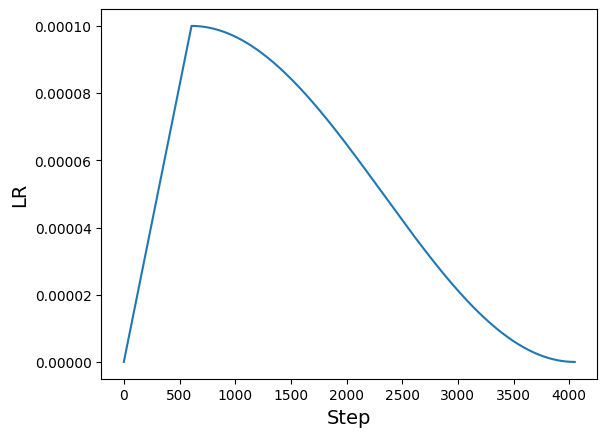

In [30]:
class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
        self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps
    ):
        super().__init__()

        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total_steps must be larger or equal to warmup_steps.")

        cos_annealed_lr = tf.cos(
            self.pi
            * (tf.cast(step, tf.float32) - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)
        )
        learning_rate = 0.5 * self.learning_rate_base * (1 + cos_annealed_lr)

        if self.warmup_steps > 0:
            if self.learning_rate_base < self.warmup_learning_rate:
                raise ValueError(
                    "Learning_rate_base must be larger or equal to "
                    "warmup_learning_rate."
                )
            slope = (
                self.learning_rate_base - self.warmup_learning_rate
            ) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            learning_rate = tf.where(
                step < self.warmup_steps, warmup_rate, learning_rate
            )
        return tf.where(
            step > self.total_steps, 0.0, learning_rate, name="learning_rate"
        )


total_steps = int(len(train_ds) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    learning_rate_base=LEARNING_RATE,
    total_steps=total_steps,
    warmup_learning_rate=0.0,
    warmup_steps=warmup_steps,
)

lrs = [scheduled_lrs(step) for step in range(total_steps)]
plt.plot(lrs)
plt.xlabel("Step", fontsize=14)
plt.ylabel("LR", fontsize=14)
plt.show()

# Assemble the callbacks.
train_callbacks = [TrainMonitor(epoch_interval=5)]

In [31]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=scheduled_lrs, decay=WEIGHT_DECAY
)

# Compile and pretrain the model.
mae_model.compile(
    optimizer=optimizer, loss=tf.keras.losses.MeanSquaredError(), metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

Epoch 1/50


81/81 [==============================] - ETA: 0s - loss: 0.0862 - mean_absolute_error: 0.2398
Idx chosen: 10


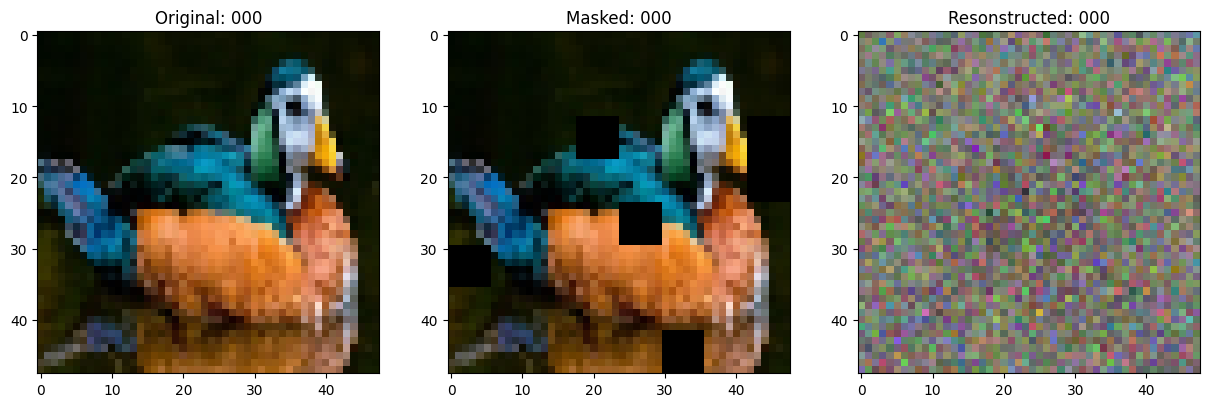

81/81 [==============================] - 18s 123ms/step - loss: 0.0862 - mean_absolute_error: 0.2398 - val_loss: 0.0674 - val_mean_absolute_error: 0.2141
Epoch 2/50
81/81 [==============================] - 8s 94ms/step - loss: 0.0610 - mean_absolute_error: 0.2044 - val_loss: 0.0591 - val_mean_absolute_error: 0.2012
Epoch 3/50
81/81 [==============================] - 8s 94ms/step - loss: 0.0588 - mean_absolute_error: 0.2011 - val_loss: 0.0585 - val_mean_absolute_error: 0.2001
Epoch 4/50
81/81 [==============================] - 8s 94ms/step - loss: 0.0539 - mean_absolute_error: 0.1902 - val_loss: 0.0504 - val_mean_absolute_error: 0.1816
Epoch 5/50
81/81 [==============================] - 8s 97ms/step - loss: 0.0486 - mean_absolute_error: 0.1776 - val_loss: 0.0485 - val_mean_absolute_error: 0.1766
Epoch 6/50
81/81 [==============================] - ETA: 0s - loss: 0.0474 - mean_absolute_error: 0.1745
Idx chosen: 7


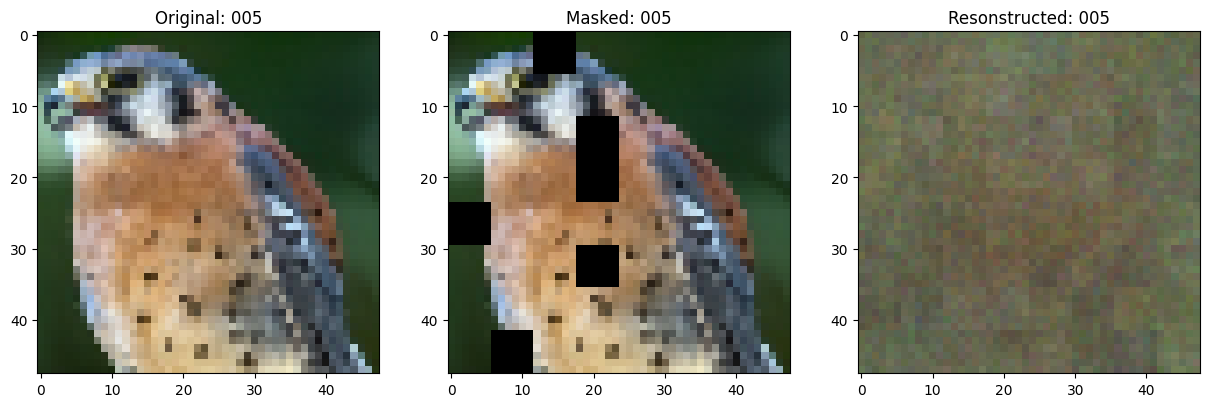

81/81 [==============================] - 8s 97ms/step - loss: 0.0474 - mean_absolute_error: 0.1745 - val_loss: 0.0482 - val_mean_absolute_error: 0.1760
Epoch 7/50
81/81 [==============================] - 8s 93ms/step - loss: 0.0472 - mean_absolute_error: 0.1740 - val_loss: 0.0468 - val_mean_absolute_error: 0.1730
Epoch 8/50
81/81 [==============================] - 8s 101ms/step - loss: 0.0466 - mean_absolute_error: 0.1726 - val_loss: 0.0469 - val_mean_absolute_error: 0.1724
Epoch 9/50
81/81 [==============================] - 8s 94ms/step - loss: 0.0457 - mean_absolute_error: 0.1699 - val_loss: 0.0451 - val_mean_absolute_error: 0.1694
Epoch 10/50
81/81 [==============================] - 8s 98ms/step - loss: 0.0457 - mean_absolute_error: 0.1698 - val_loss: 0.0452 - val_mean_absolute_error: 0.1684
Epoch 11/50
81/81 [==============================] - ETA: 0s - loss: 0.0453 - mean_absolute_error: 0.1687
Idx chosen: 28


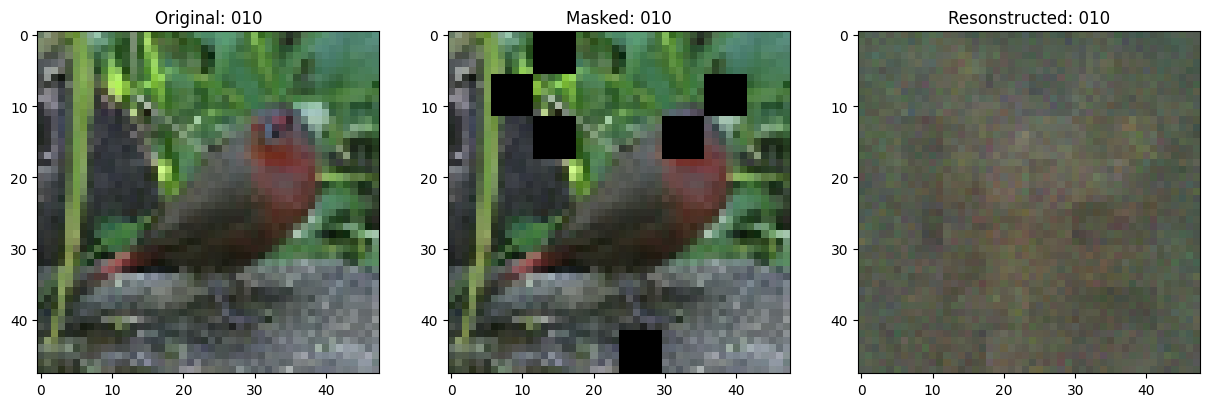

81/81 [==============================] - 8s 100ms/step - loss: 0.0453 - mean_absolute_error: 0.1687 - val_loss: 0.0455 - val_mean_absolute_error: 0.1693
Epoch 12/50
81/81 [==============================] - 8s 97ms/step - loss: 0.0451 - mean_absolute_error: 0.1684 - val_loss: 0.0452 - val_mean_absolute_error: 0.1684
Epoch 13/50
81/81 [==============================] - 8s 95ms/step - loss: 0.0442 - mean_absolute_error: 0.1660 - val_loss: 0.0447 - val_mean_absolute_error: 0.1670
Epoch 14/50
81/81 [==============================] - 8s 95ms/step - loss: 0.0445 - mean_absolute_error: 0.1666 - val_loss: 0.0439 - val_mean_absolute_error: 0.1659
Epoch 15/50
81/81 [==============================] - 8s 95ms/step - loss: 0.0440 - mean_absolute_error: 0.1656 - val_loss: 0.0449 - val_mean_absolute_error: 0.1683
Epoch 16/50
81/81 [==============================] - ETA: 0s - loss: 0.0442 - mean_absolute_error: 0.1660
Idx chosen: 20


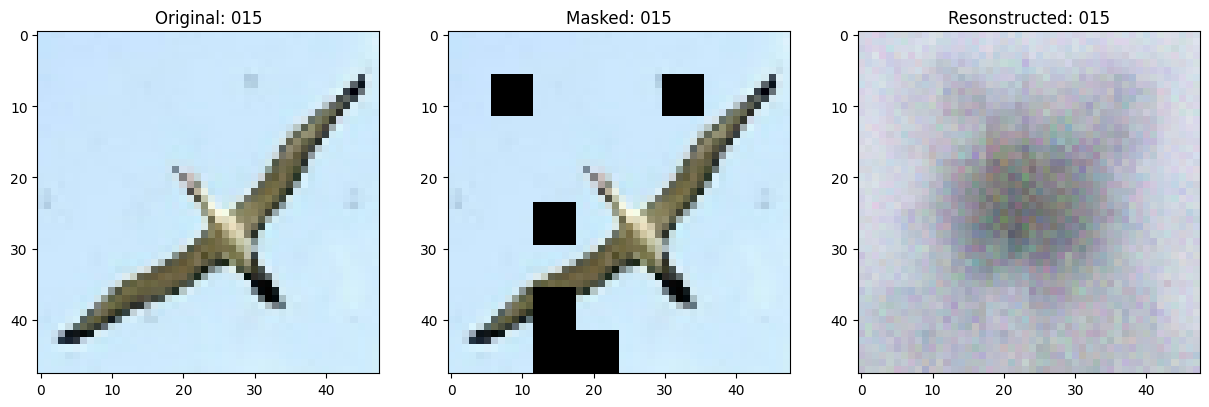

81/81 [==============================] - 10s 119ms/step - loss: 0.0442 - mean_absolute_error: 0.1660 - val_loss: 0.0444 - val_mean_absolute_error: 0.1668
Epoch 17/50
81/81 [==============================] - 9s 104ms/step - loss: 0.0437 - mean_absolute_error: 0.1646 - val_loss: 0.0448 - val_mean_absolute_error: 0.1674
Epoch 18/50
81/81 [==============================] - 10s 118ms/step - loss: 0.0440 - mean_absolute_error: 0.1654 - val_loss: 0.0441 - val_mean_absolute_error: 0.1669
Epoch 19/50
81/81 [==============================] - 8s 103ms/step - loss: 0.0440 - mean_absolute_error: 0.1655 - val_loss: 0.0447 - val_mean_absolute_error: 0.1663
Epoch 20/50
81/81 [==============================] - 8s 98ms/step - loss: 0.0439 - mean_absolute_error: 0.1651 - val_loss: 0.0441 - val_mean_absolute_error: 0.1668
Epoch 21/50
81/81 [==============================] - ETA: 0s - loss: 0.0442 - mean_absolute_error: 0.1657
Idx chosen: 6


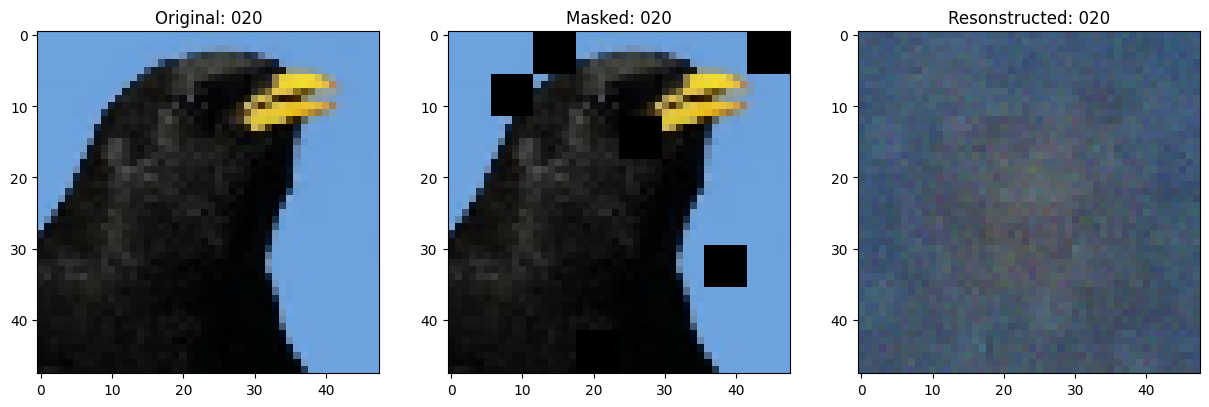

81/81 [==============================] - 9s 110ms/step - loss: 0.0442 - mean_absolute_error: 0.1657 - val_loss: 0.0448 - val_mean_absolute_error: 0.1676
Epoch 22/50
81/81 [==============================] - 8s 101ms/step - loss: 0.0440 - mean_absolute_error: 0.1654 - val_loss: 0.0433 - val_mean_absolute_error: 0.1641
Epoch 23/50
81/81 [==============================] - 9s 109ms/step - loss: 0.0440 - mean_absolute_error: 0.1652 - val_loss: 0.0441 - val_mean_absolute_error: 0.1668
Epoch 24/50
81/81 [==============================] - 8s 100ms/step - loss: 0.0434 - mean_absolute_error: 0.1642 - val_loss: 0.0439 - val_mean_absolute_error: 0.1658
Epoch 25/50
81/81 [==============================] - 8s 100ms/step - loss: 0.0440 - mean_absolute_error: 0.1652 - val_loss: 0.0440 - val_mean_absolute_error: 0.1660
Epoch 26/50
81/81 [==============================] - ETA: 0s - loss: 0.0436 - mean_absolute_error: 0.1644
Idx chosen: 25


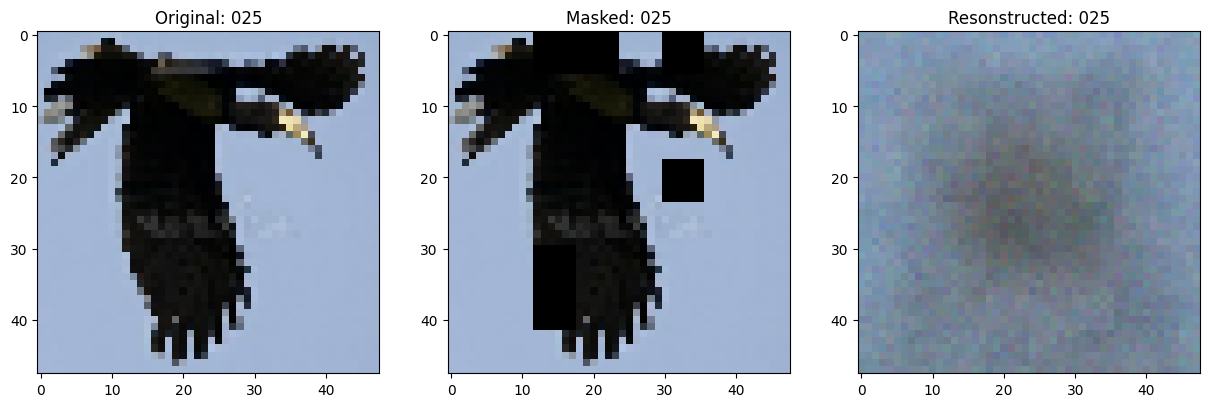

81/81 [==============================] - 8s 103ms/step - loss: 0.0436 - mean_absolute_error: 0.1644 - val_loss: 0.0437 - val_mean_absolute_error: 0.1650
Epoch 27/50
81/81 [==============================] - 8s 98ms/step - loss: 0.0437 - mean_absolute_error: 0.1646 - val_loss: 0.0443 - val_mean_absolute_error: 0.1663
Epoch 28/50
81/81 [==============================] - 8s 94ms/step - loss: 0.0436 - mean_absolute_error: 0.1646 - val_loss: 0.0430 - val_mean_absolute_error: 0.1640
Epoch 29/50
81/81 [==============================] - 8s 97ms/step - loss: 0.0436 - mean_absolute_error: 0.1649 - val_loss: 0.0446 - val_mean_absolute_error: 0.1670
Epoch 30/50
81/81 [==============================] - 8s 97ms/step - loss: 0.0435 - mean_absolute_error: 0.1644 - val_loss: 0.0441 - val_mean_absolute_error: 0.1660
Epoch 31/50
81/81 [==============================] - ETA: 0s - loss: 0.0436 - mean_absolute_error: 0.1646
Idx chosen: 18


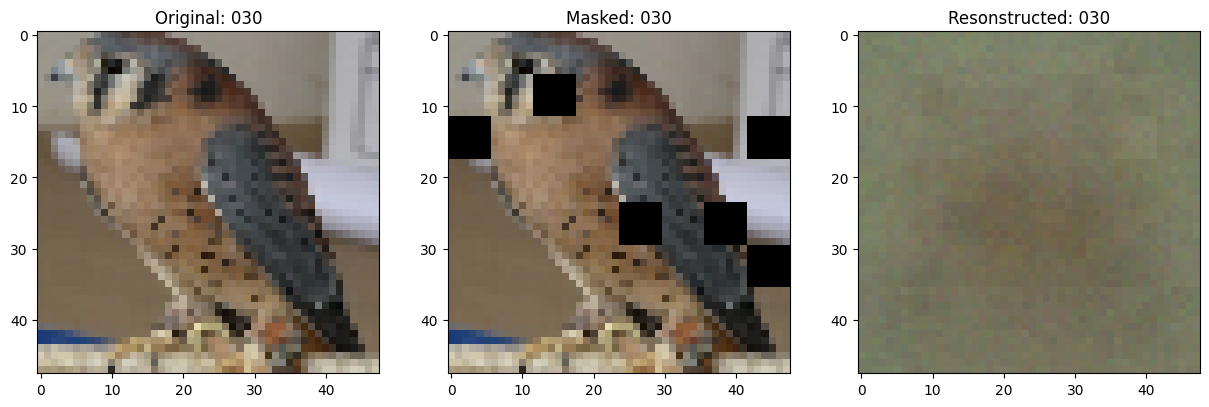

81/81 [==============================] - 9s 113ms/step - loss: 0.0436 - mean_absolute_error: 0.1646 - val_loss: 0.0448 - val_mean_absolute_error: 0.1676
Epoch 32/50
81/81 [==============================] - 9s 112ms/step - loss: 0.0437 - mean_absolute_error: 0.1648 - val_loss: 0.0426 - val_mean_absolute_error: 0.1629
Epoch 33/50
81/81 [==============================] - 8s 97ms/step - loss: 0.0438 - mean_absolute_error: 0.1647 - val_loss: 0.0439 - val_mean_absolute_error: 0.1652
Epoch 34/50
81/81 [==============================] - 8s 95ms/step - loss: 0.0432 - mean_absolute_error: 0.1633 - val_loss: 0.0444 - val_mean_absolute_error: 0.1666
Epoch 35/50
81/81 [==============================] - 8s 98ms/step - loss: 0.0439 - mean_absolute_error: 0.1647 - val_loss: 0.0434 - val_mean_absolute_error: 0.1640
Epoch 36/50
81/81 [==============================] - ETA: 0s - loss: 0.0431 - mean_absolute_error: 0.1636
Idx chosen: 22


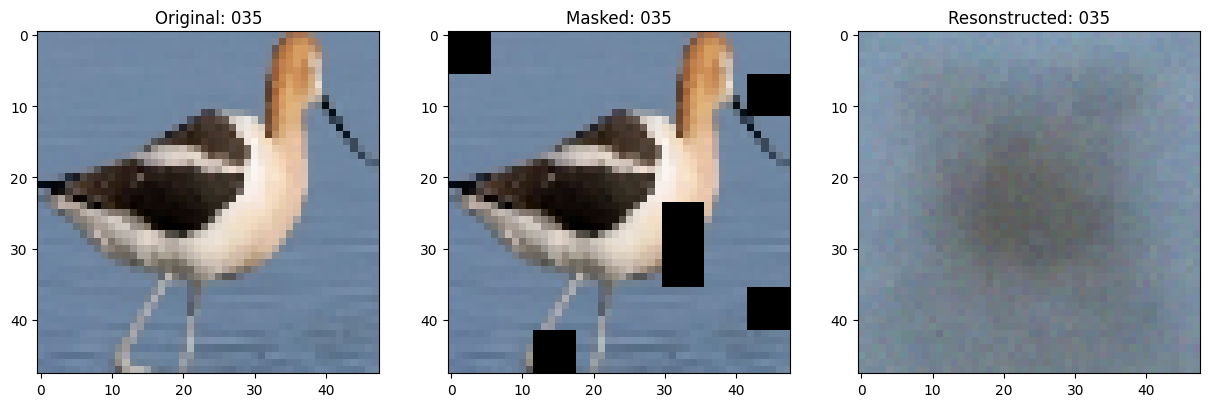

81/81 [==============================] - 9s 106ms/step - loss: 0.0431 - mean_absolute_error: 0.1636 - val_loss: 0.0446 - val_mean_absolute_error: 0.1662
Epoch 37/50
81/81 [==============================] - 9s 116ms/step - loss: 0.0434 - mean_absolute_error: 0.1637 - val_loss: 0.0447 - val_mean_absolute_error: 0.1673
Epoch 38/50
81/81 [==============================] - 9s 112ms/step - loss: 0.0436 - mean_absolute_error: 0.1644 - val_loss: 0.0437 - val_mean_absolute_error: 0.1652
Epoch 39/50
81/81 [==============================] - 8s 101ms/step - loss: 0.0443 - mean_absolute_error: 0.1657 - val_loss: 0.0437 - val_mean_absolute_error: 0.1657
Epoch 40/50
81/81 [==============================] - 8s 102ms/step - loss: 0.0435 - mean_absolute_error: 0.1644 - val_loss: 0.0442 - val_mean_absolute_error: 0.1660
Epoch 41/50
81/81 [==============================] - ETA: 0s - loss: 0.0442 - mean_absolute_error: 0.1656
Idx chosen: 10


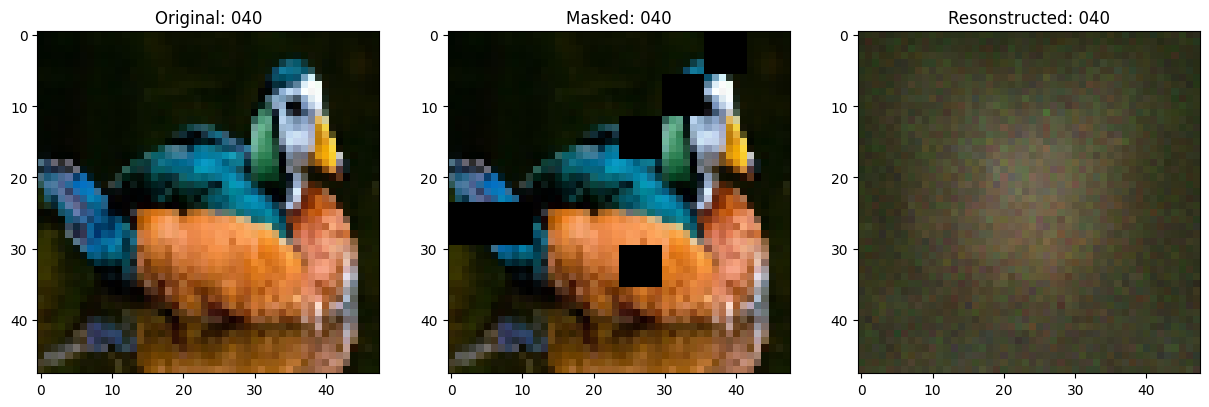

81/81 [==============================] - 8s 104ms/step - loss: 0.0442 - mean_absolute_error: 0.1656 - val_loss: 0.0440 - val_mean_absolute_error: 0.1659
Epoch 42/50
81/81 [==============================] - 8s 101ms/step - loss: 0.0433 - mean_absolute_error: 0.1636 - val_loss: 0.0436 - val_mean_absolute_error: 0.1649
Epoch 43/50
81/81 [==============================] - 9s 106ms/step - loss: 0.0439 - mean_absolute_error: 0.1650 - val_loss: 0.0441 - val_mean_absolute_error: 0.1655
Epoch 44/50
81/81 [==============================] - 9s 108ms/step - loss: 0.0436 - mean_absolute_error: 0.1643 - val_loss: 0.0440 - val_mean_absolute_error: 0.1661
Epoch 45/50
81/81 [==============================] - 8s 101ms/step - loss: 0.0432 - mean_absolute_error: 0.1634 - val_loss: 0.0442 - val_mean_absolute_error: 0.1654
Epoch 46/50
81/81 [==============================] - ETA: 0s - loss: 0.0437 - mean_absolute_error: 0.1646
Idx chosen: 10


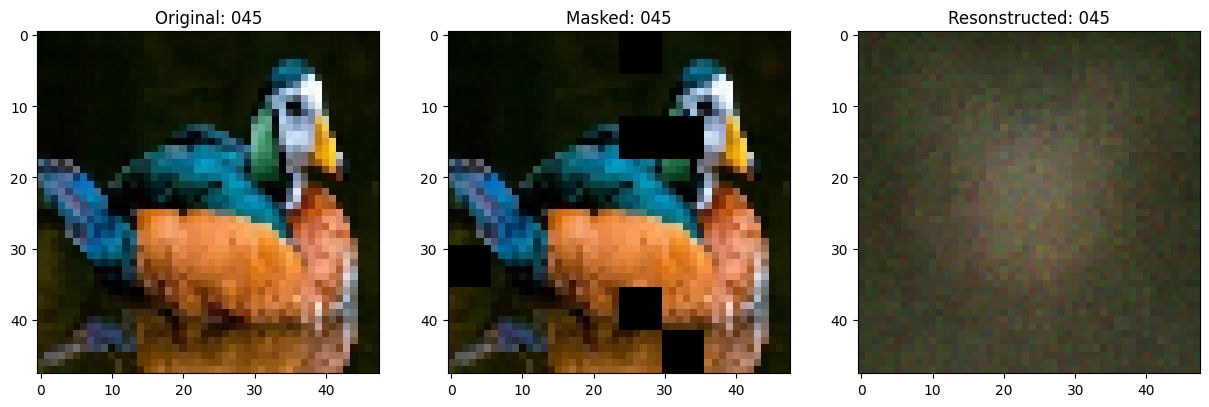

81/81 [==============================] - 9s 112ms/step - loss: 0.0437 - mean_absolute_error: 0.1646 - val_loss: 0.0443 - val_mean_absolute_error: 0.1663
Epoch 47/50
81/81 [==============================] - 8s 100ms/step - loss: 0.0437 - mean_absolute_error: 0.1646 - val_loss: 0.0430 - val_mean_absolute_error: 0.1638
Epoch 48/50
81/81 [==============================] - 8s 103ms/step - loss: 0.0434 - mean_absolute_error: 0.1642 - val_loss: 0.0452 - val_mean_absolute_error: 0.1683
Epoch 49/50
81/81 [==============================] - 8s 103ms/step - loss: 0.0432 - mean_absolute_error: 0.1635 - val_loss: 0.0433 - val_mean_absolute_error: 0.1644
Epoch 50/50
81/81 [==============================] - 9s 109ms/step - loss: 0.0432 - mean_absolute_error: 0.1636 - val_loss: 0.0442 - val_mean_absolute_error: 0.1665


In [32]:
history = mae_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)

In [33]:
y_preds = []
y_val = []
for images in val_ds:
    out = mae_model.forward_predict(images).numpy()
    y_preds.extend(out)
    y_val.extend(images.numpy())

In [34]:
np.array(y_preds).shape

(641, 64, 108)

In [35]:
np.array(y_val).shape

(641, 48, 48, 3)

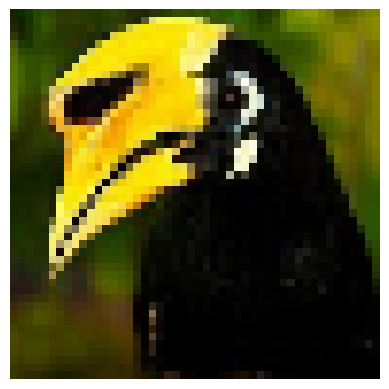

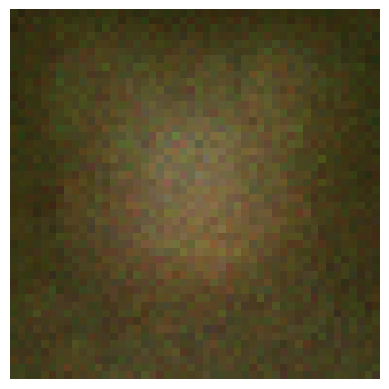

In [45]:
image = y_val[378].astype(int)
plt.imshow(image)
plt.axis("off")
plt.show()

image = patch_layer.reconstruct_from_patch(y_preds[378])
plt.imshow(image)
plt.axis("off")
plt.show()

In [37]:
image.shape

TensorShape([48, 48, 3])

In [38]:
from skimage.metrics import structural_similarity as ssim


In [39]:
patch_layer.reconstruct_from_patch(y_preds[1]).numpy().shape

(48, 48, 3)

In [40]:
ssim(patch_layer.reconstruct_from_patch(y_preds[1]).numpy(), y_val[1], multichannel=True,  data_range=255, win_size=7, channel_axis=-1)

0.0009940402

In [41]:
ssim_score = []
for i,j in zip(y_preds, y_val):
    ssim_score.append(ssim(patch_layer.reconstruct_from_patch(i).numpy(), j, multichannel=True,  data_range=255, win_size=7, channel_axis=-1))

In [42]:
np.mean(ssim_score)

0.0041165487

In [44]:
np.argmax(ssim_score)

378

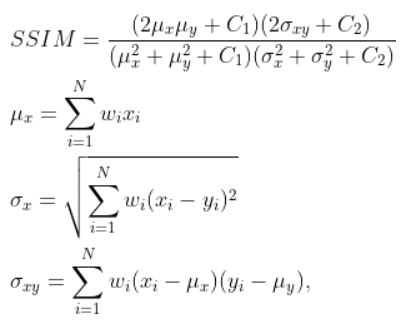